In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI

In [2]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [3]:
model="deepseek-r1-distill-llama-70b"
llm=ChatGroq(model=model)
llm.invoke('hi how r u')

AIMessage(content="<think>\n\n</think>\n\nHi! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with whatever you need. How are *you* doing? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 7, 'total_tokens': 51, 'completion_time': 0.232722397, 'prompt_time': 0.000175608, 'queue_time': 0.053345062, 'total_time': 0.232898005}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--7f833fa6-e593-4b92-956e-d727cc8e3eae-0', usage_metadata={'input_tokens': 7, 'output_tokens': 44, 'total_tokens': 51})

AGENT is nothing but LLM + TOOLS

---->where LLM is the brain

---->and TOOL is the action which it takes [multiple tools]

MULTI AGENT is nothing but more thatn one agent where multiple agent taking to each other

--->Two types discussed here 

(1) Network

(2) Supervisor

In [4]:
#Command is important to conneect from one agent to other
#it is for network or cloabrative multi agent
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool

In [5]:
#dummy checks basic
def add_number(state):
    result=state["num1"]+state["num2"]
    print(f"addition {result}")
    return Command(goto="multiply",update={"sum":result})

state={"num1":10,"num2":20}

add_number(state)

addition 30


Command(update={'sum': 30}, goto='multiply')

In [6]:
#calculation is done here
@tool
def transfer_to_multiplcation_expert():
    """Agst Multiplication Agent for help"""
    return


In [7]:
@tool
def transfer_to_additional_expert():
    """Agst Multiplication Agent for help"""
    return


In [8]:
import operator
from typing import List
from typing_extensions import Literal
from langgraph.graph.message import add_messages
from pydantic import BaseModel , Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

class Agentstate(TypedDict):
    message: Annotated[Sequence[BaseMessage], operator.add]
    Name:str
    Age:int


In [9]:
llm_with_tool=llm.bind_tools([transfer_to_multiplcation_expert])

In [10]:
response=llm_with_tool.invoke("what is 2 + 2")

In [11]:
response.content

''

In [12]:
response.tool_calls

[{'name': 'transfer_to_multiplcation_expert',
  'args': {},
  'id': 'sfg7k8x7g',
  'type': 'tool_call'}]

In [13]:
def additional_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]:
    
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    #calculation is done in the tool
    ai_msg = llm.bind_tools([transfer_to_multiplcation_expert]).invoke(messages)
    
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}

In [14]:
##Agent2
def multiplication_expert(state:MessagesState)-> Command[Literal["additional_expert", "__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = llm.bind_tools([transfer_to_multiplcation_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [15]:
graph=StateGraph(MessagesState)
graph.add_node("additional_expert",additional_expert)
graph.add_node("multiplication_expert",multiplication_expert)

In [16]:
graph.add_edge(START,"additional_expert")


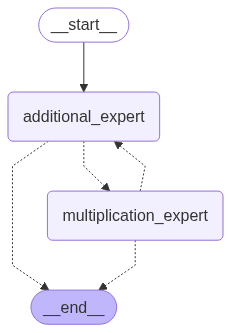

In [17]:
app=graph.compile()

from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))


In [18]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='47c31661-4921-4048-b9a1-53887e61f6a4'),
  AIMessage(content='The result of (3 + 5) * 12 is 96.\n\nStep-by-step explanation:\n1. Calculate the addition inside the parentheses: 3 + 5 = 8.\n2. Multiply the result by 12: 8 * 12 = 96.\n\nAnswer: 96', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 343, 'prompt_tokens': 163, 'total_tokens': 506, 'completion_time': 1.247272727, 'prompt_time': 0.01670707, 'queue_time': 0.05559554, 'total_time': 1.263979797}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--0b6500e5-484d-4a36-b846-7a0e99b5a0c5-0', usage_metadata={'input_tokens': 163, 'output_tokens': 343, 'total_tokens': 506})]}

In [19]:
#!pip install langchain-experimental
from langchain_experimental.utilities.python import PythonREPL

IN RealTime

In [20]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool=DuckDuckGoSearchRun()
search_tool.invoke("who is a current pm of uk?")

"British Prime Minister Keir Starmer delivers a speech following his first Cabinet meeting as Prime Minister, in London, July 6, 2024. Sir Keir Starmer is the new prime minister of the United Kingdom. The 2024 general election saw the Conservative Party lose power for the first time since 2010. Keir Starmer, a human rights lawyer from a small town in southern England, is the new prime minister of the United Kingdom. His victory on July 4 was overwhelming. Yet Britain barely knows who he is. Starmer has been a politician for only nine years, and since being crowned U.K. Labour leader in 2020 has steered his party from its worst election defeat in almost a century to become the ... Keir Starmer 's tenure as Prime Minister of the United Kingdom began on 5 July 2024 when he accepted an invitation from King Charles III to form a government, succeeding Rishi Sunak of the Conservative Party. As prime minister he is serving concurrently as First Lord of the Treasury, Minister for the Civil Ser

In [21]:
# search_tool=DuckDuckGoSearchRun()

import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [22]:
code="print(10+2)"
repl=PythonREPL()
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'12\n'

In [23]:
from typing import Annotated

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )
    

<>:15: SyntaxWarning: invalid escape sequence '\`'
<>:15: SyntaxWarning: invalid escape sequence '\`'
<>:15: SyntaxWarning: invalid escape sequence '\`'
<>:15: SyntaxWarning: invalid escape sequence '\`'
/var/folders/4m/z36lvyp57r37vs_gdh88c2mc0000gn/T/ipykernel_6995/2587950130.py:15: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
/var/folders/4m/z36lvyp57r37vs_gdh88c2mc0000gn/T/ipykernel_6995/2587950130.py:15: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [24]:
python_repl_tool
print(python_repl_tool.invoke(code))

Successfully executed:
\`\`\`python
print(10+2)
\`\`\`
Stdout: 12


If you have completed all tasks, respond with FINAL ANSWER.


In [25]:
def make_system_prompt(instruction:str)->str:
    return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )

In [26]:
make_system_prompt("You can only do research. You are working with a chart generator colleague.")

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nYou can only do research. You are working with a chart generator colleague."

In [27]:
from langchain_core.messages import BaseMessage
def get_next_node(last_message:BaseMessage, goto:str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto

In [28]:
#agent1
def research_node(state:MessagesState)->Command[Literal["chart_generator", END]]:
    #multiple calls is done here
    #final answer after many back anf forth calls

    research_agent=create_react_agent(
        llm,
        tools=[search_tool],
        prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ), 
        )
    
    result=research_agent.invoke(state)
    goto=get_next_node(result["messages"][-1],"chart_generator")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")
    return Command(update={"messages": result["messages"]},goto=goto)

In [29]:
#agent2
#this chart node calls the python repl tool
def chart_node(state:MessagesState)-> Command[Literal["researcher", END]]:
    chart_agent=create_react_agent(
        llm,
        tools=[python_repl_tool],
        prompt=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
        )
    result=chart_agent.invoke(state)
    goto=get_next_node(result["messages"][-1],"researcher")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")
    return Command(update={"messages": result["messages"]},goto=goto)

In [30]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()

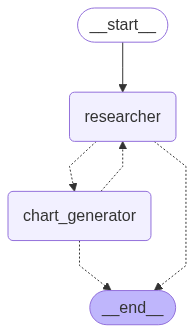

In [31]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

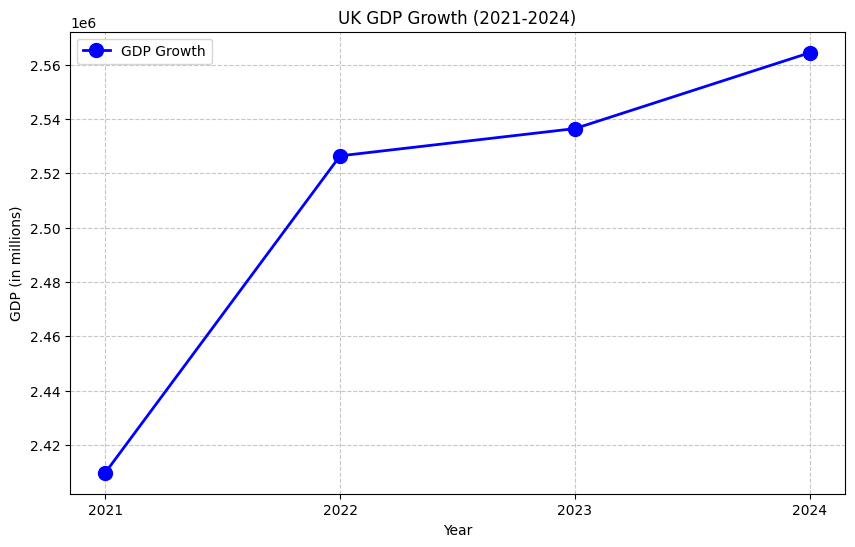

In [32]:
result=app.invoke({"messages": [("user","get the UK's GDP over the past 3 years from (2021 -2024), then make a line chart of it.Once you make the chart, finish.")],})

In [33]:
result["message"][-1].content()

KeyError: 'message'